# Number Recognition using Machine Learning

## Objective

The objective of this project is to build a Machine Learning model capable of recognizing handwritten digits (0–9). The images are first preprocessed and converted into numerical feature vectors by flattening each image into a one-dimensional array.

The workflow includes:

- Loading the dataset
- Reading image paths from CSV
- Image preprocessing
- Flattening images
- Creating feature vectors
- Data preprocessing
- Model training
- Comparing multiple ML algorithms
- Hyperparameter tuning
- Saving the best model
- Making predictions on unseen images


# **Creation of csv file from the given zip file.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

os.listdir('/content/drive/MyDrive')

['README.md',
 'GetMyOS',
 'Torrent',
 'torrent downloader.ipynb',
 'Videos ',
 "Mother's day files",
 'VMware-workstation-pro-16.1.1-17801498.exe',
 '12004587_SaiKalyanK_CA1 (1).pptx',
 '12004587_SaiKalyanK_CA1.pptx',
 'Sai Kalyan CV Final.pdf',
 'SAI KALYAN CV.pdf',
 'Clean Minimalist CV Resume Template.pdf',
 'Clean Minimalist CV Resume Template.gdoc',
 'Internship Letter - Techsol Life Sciences - Sai Kalyan Katineni.pdf',
 'Manali Photos',
 'how to remove null values using for loops and lists and do not use dropNA in pandas dataframe',
 'write a program for creating a snake game in python',
 'Payment-1556.pdf',
 'Company Details.pdf',
 'PERSONAL',
 'Sai Kalyan.pdf',
 'PAN_Apple.pdf',
 'Tata_AIG_Motor_Policy_Schedule_3184_6204897533.pdf',
 'Adhaar (1).pdf',
 'Adhaar.pdf',
 'Sai Kalyan.gdoc',
 'Sai Kalyan_Katineni_Resume.docx',
 'IMG_2348 (1).jpeg',
 'IMG_2348.jpeg',
 'Colab Notebooks',
 '02-03-2026.ipynb',
 '02-03-2025_HW.ipynb',
 '03-03-2026.ipynb',
 '04-03-2026.ipynb',
 '05-03-202

In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/ML Assignments/archive (7).zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [4]:
import os

os.listdir("/content/dataset")

['trainingSet.tar.gz',
 'trainingSample',
 'testSet.tar.gz',
 'testSet',
 'trainingSet',
 'testSample']

In [5]:
import pandas as pd

csv_path = "/content/training_labels.csv"

df = pd.read_csv(csv_path)

df.head()

,image_path,label
0,/content/dataset/trainingSet/trainingSet/0/img...,0
1,/content/dataset/trainingSet/trainingSet/0/img...,0
2,/content/dataset/trainingSet/trainingSet/0/img...,0
3,/content/dataset/trainingSet/trainingSet/0/img...,0
4,/content/dataset/trainingSet/trainingSet/0/img...,0


In [6]:
print(df.columns)

print(df.iloc[0])

print(df.iloc[0]["image_path"])

Index(['image_path', 'label'], dtype='object')
image_path    /content/dataset/trainingSet/trainingSet/0/img...
label                                                         0
Name: 0, dtype: object
/content/dataset/trainingSet/trainingSet/0/img_1.jpg


In [7]:
BASE_PATH = "/content/dataset/archive (7)/trainingSet"

In [8]:
import os

sample_path = os.path.join(BASE_PATH, df.iloc[0]["image_path"])

print(sample_path)
print(os.path.exists(sample_path))

/content/dataset/trainingSet/trainingSet/0/img_1.jpg
True


In [9]:
import os
import pandas as pd

In [10]:
dataset_path = "/content/dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*80)

/content/dataset
Folders: ['trainingSample', 'testSet', 'trainingSet', 'testSample']
Files: ['trainingSet.tar.gz', 'testSet.tar.gz']
--------------------------------------------------------------------------------
/content/dataset/trainingSample
Folders: ['trainingSample']
Files: ['img_224.jpg', 'img_214.jpg', 'img_46.jpg', 'img_8.jpg', 'img_521.jpg']
--------------------------------------------------------------------------------
/content/dataset/trainingSample/trainingSample
Folders: ['4', '7', '0', '8', '1']
Files: []
--------------------------------------------------------------------------------
/content/dataset/trainingSample/trainingSample/4
Folders: []
Files: ['img_168.jpg', 'img_170.jpg', 'img_205.jpg', 'img_291.jpg', 'img_541.jpg']
--------------------------------------------------------------------------------
/content/dataset/trainingSample/trainingSample/7
Folders: []
Files: ['img_521.jpg', 'img_308.jpg', 'img_304.jpg', 'img_116.jpg', 'img_358.jpg']
-----------------------

In [11]:
import os
import pandas as pd

dataset_path = "/content/dataset/trainingSet/trainingSet"

data = []

for label in sorted(os.listdir(dataset_path)):

    label_folder = os.path.join(dataset_path, label)

    if os.path.isdir(label_folder):

        for image in sorted(os.listdir(label_folder)):

            if image.endswith((".jpg", ".jpeg", ".png")):

                image_path = os.path.join(label_folder, image)

                data.append({
                    "image_path": image_path,
                    "label": int(label)
                })

df = pd.DataFrame(data)

print(df.head())

print("\nTotal Images :", len(df))

                                          image_path  label
0  /content/dataset/trainingSet/trainingSet/0/img...      0
1  /content/dataset/trainingSet/trainingSet/0/img...      0
2  /content/dataset/trainingSet/trainingSet/0/img...      0
3  /content/dataset/trainingSet/trainingSet/0/img...      0
4  /content/dataset/trainingSet/trainingSet/0/img...      0

Total Images : 42000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  42000 non-null  object
 1   label       42000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 656.4+ KB


In [13]:
df['label'].value_counts().sort_index()

,count
label,
0,4132
1,4684
2,4177
3,4351
4,4072
5,3795
6,4137
7,4401
8,4063


In [14]:
csv_name = "training_labels_final.csv"

df.to_csv(csv_name, index=False)

print("CSV Saved Successfully")

CSV Saved Successfully


# **Import Required Libraries**

In [15]:
import os
import cv2
import mediapipe as mp
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier



# Load the CSV File

The dataset contains image file paths and corresponding labels.

The CSV file consists of two columns:

- relative_path
- label

Each image path is used to locate the image, while the label represents the digit (0–9).

In [16]:
df = pd.read_csv("training_labels.csv")

df.head()

,image_path,label
0,/content/dataset/trainingSet/trainingSet/0/img...,0
1,/content/dataset/trainingSet/trainingSet/0/img...,0
2,/content/dataset/trainingSet/trainingSet/0/img...,0
3,/content/dataset/trainingSet/trainingSet/0/img...,0
4,/content/dataset/trainingSet/trainingSet/0/img...,0


In [17]:
df.shape

(42000, 2)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  42000 non-null  object
 1   label       42000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 656.4+ KB


In [19]:
df['label'].value_counts().sort_index()

,count
label,
0,4132
1,4684
2,4177
3,4351
4,4072
5,3795
6,4137
7,4401
8,4063


# Read Images

Each image is loaded using OpenCV in grayscale mode.

Since machine learning algorithms require numerical input, each image will be converted into a flattened one-dimensional vector.

# **Verify and Read single Image**

In [20]:
import os

sample_path = os.path.join(BASE_PATH, df.iloc[0]["image_path"])

print(sample_path)
print(os.path.exists(sample_path))

/content/dataset/trainingSet/trainingSet/0/img_1.jpg
True


(28, 28)


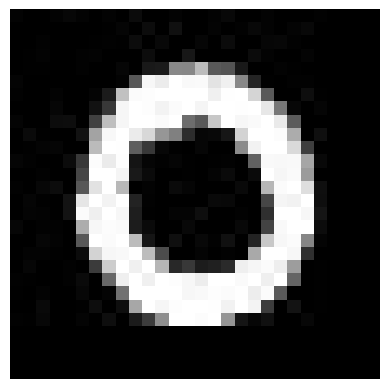

In [21]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

print(img.shape)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [22]:
from tqdm import tqdm
import cv2

images = []
labels = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    image_path = row["image_path"]      # Correct column name
    label = row["label"]

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    images.append(img)
    labels.append(label)
print("\n")
print("Total Images Loaded:", len(images))

100%|██████████| 42000/42000 [00:06<00:00, 6941.48it/s]



Total Images Loaded: 42000


# Visualize Sample Images

Before preprocessing, it is always good practice to inspect a few images from the dataset.

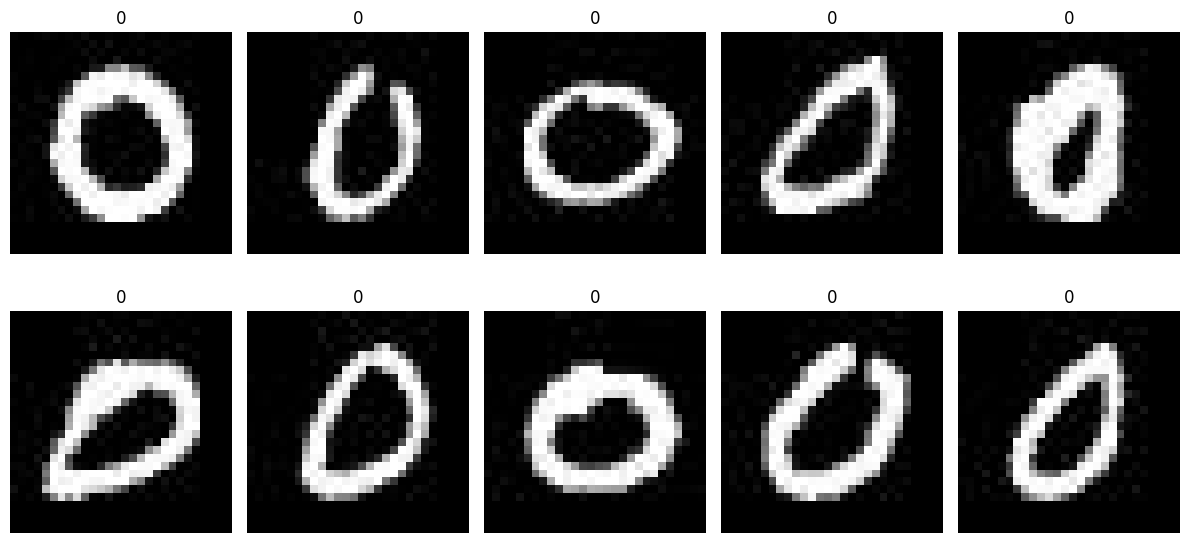

In [23]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Flatten the Images

Machine learning algorithms cannot work directly with 2D images.

Each image is therefore converted into a one-dimensional vector by flattening the pixel values.

For example,

28 × 28 image

↓

784 features

In [24]:
print(images[0].shape)

(28, 28)


In [25]:
flattened_images = []

for image in images:
    flattened_images.append(image.flatten())

print("Total Flattened Images :", len(flattened_images))

Total Flattened Images : 42000


In [26]:
print(flattened_images[0].shape)

(784,)


# Convert Lists into NumPy Arrays

NumPy arrays provide faster computation and are required by most machine learning algorithms.

In [27]:
X = np.array(flattened_images)

y = np.array(labels)

In [28]:
print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


# Create DataFrame

Creating a DataFrame helps us inspect the dataset before training the machine learning models.

In [29]:
df_features = pd.DataFrame(X)

df_features["label"] = y

df_features.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,3,0,0,3,7,3,0,3,0,11,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,8,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df_features.shape

(42000, 785)

# Check Missing Values and Duplicates

In [31]:
df_features.isnull().sum().sum()

np.int64(0)

In [32]:
df_features.duplicated().sum()

np.int64(0)

# Train-Test Split

The dataset is divided into training and testing sets.

80% → Training

20% → Testing

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [34]:
print(X_train.shape)

print(X_test.shape)

(33600, 784)
(8400, 784)


# Feature Scaling

Pixel values range from 0 to 255.

Scaling the values improves the performance of distance-based and optimization-based machine learning algorithms such as KNN, Logistic Regression, and SVM.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train.shape)

print(X_test.shape)

(33600, 784)
(8400, 784)


# Model Building

In this section, we train multiple Machine Learning algorithms on the flattened handwritten digit dataset.

The following models will be compared:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- Gaussian Naive Bayes

The best-performing model will later be tuned using GridSearchCV.

In [36]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model_accuracy = {}

# Logistic Regression

Logistic Regression is a linear classification algorithm commonly used for multi-class classification problems.

In [37]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [38]:
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Accuracy :", lr_acc)

model_accuracy["Logistic Regression"] = lr_acc

Accuracy : 0.8967857142857143


In [39]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       827
           1       0.95      0.97      0.96       937
           2       0.86      0.87      0.87       835
           3       0.86      0.86      0.86       870
           4       0.91      0.91      0.91       814
           5       0.87      0.83      0.85       759
           6       0.93      0.94      0.93       827
           7       0.89      0.92      0.91       880
           8       0.85      0.83      0.84       813
           9       0.88      0.88      0.88       838

    accuracy                           0.90      8400
   macro avg       0.90      0.90      0.90      8400
weighted avg       0.90      0.90      0.90      8400



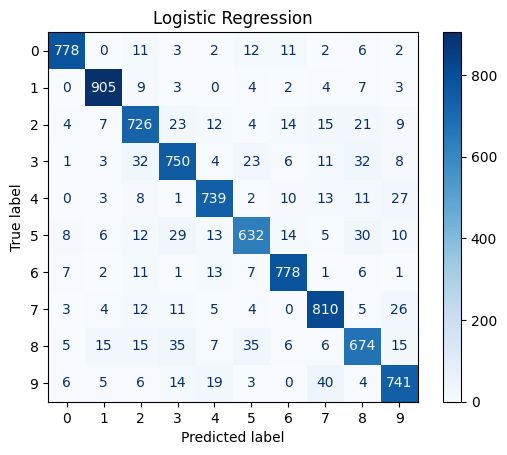

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)

plt.title("Logistic Regression")

plt.show()

# K-Nearest Neighbors

KNN classifies an image based on the majority class among its nearest neighbors.

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=3
)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [42]:
knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("Accuracy :", knn_acc)

model_accuracy["KNN"] = knn_acc

Accuracy : 0.9242857142857143


In [43]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       827
           1       0.94      0.99      0.96       937
           2       0.93      0.92      0.92       835
           3       0.88      0.92      0.90       870
           4       0.95      0.89      0.92       814
           5       0.91      0.89      0.90       759
           6       0.96      0.96      0.96       827
           7       0.92      0.91      0.91       880
           8       0.97      0.84      0.90       813
           9       0.87      0.91      0.89       838

    accuracy                           0.92      8400
   macro avg       0.93      0.92      0.92      8400
weighted avg       0.93      0.92      0.92      8400



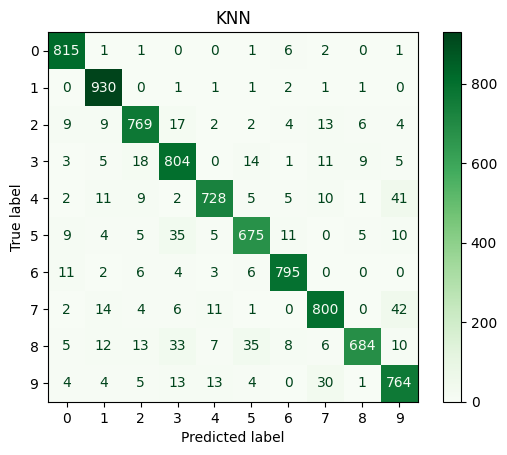

In [44]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    cmap="Greens"
)

plt.title("KNN")

plt.show()

# Decision Tree

Decision Trees classify images by recursively splitting the feature space.

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [46]:
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Accuracy :", dt_acc)

model_accuracy["Decision Tree"] = dt_acc

Accuracy : 0.84


In [47]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       827
           1       0.94      0.96      0.95       937
           2       0.82      0.82      0.82       835
           3       0.79      0.79      0.79       870
           4       0.83      0.83      0.83       814
           5       0.78      0.75      0.76       759
           6       0.86      0.85      0.86       827
           7       0.86      0.88      0.87       880
           8       0.79      0.78      0.79       813
           9       0.79      0.81      0.80       838

    accuracy                           0.84      8400
   macro avg       0.84      0.84      0.84      8400
weighted avg       0.84      0.84      0.84      8400



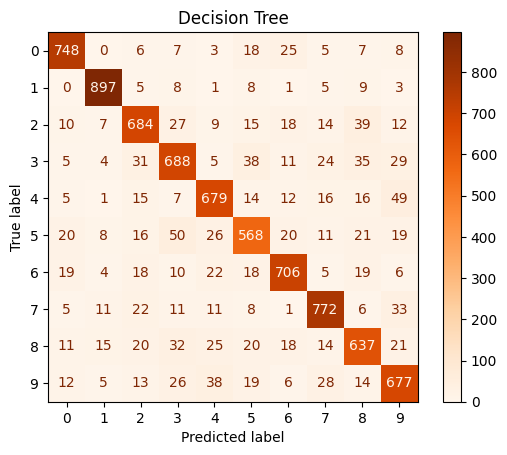

In [48]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Oranges"
)

plt.title("Decision Tree")

plt.show()

# Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [50]:
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Accuracy :", rf_acc)

model_accuracy["Random Forest"] = rf_acc

Accuracy : 0.9598809523809524


In [51]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.98      0.99      0.98       937
           2       0.96      0.95      0.96       835
           3       0.95      0.94      0.94       870
           4       0.97      0.96      0.97       814
           5       0.96      0.95      0.96       759
           6       0.97      0.98      0.97       827
           7       0.96      0.95      0.96       880
           8       0.95      0.94      0.94       813
           9       0.93      0.94      0.93       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400



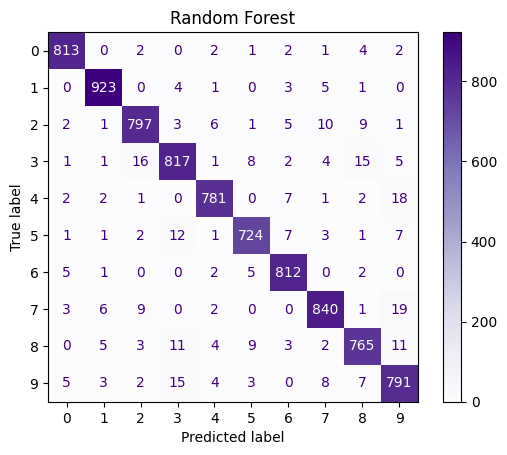

In [52]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Purples"
)

plt.title("Random Forest")

plt.show()

# Gaussian Naive Bayes

Gaussian Naive Bayes assumes feature independence and provides a simple probabilistic baseline for comparison.

In [53]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

GaussianNB()

In [54]:
nb_pred = nb.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)

print("Accuracy :", nb_acc)

model_accuracy["Gaussian Naive Bayes"] = nb_acc

Accuracy : 0.5897619047619047


In [55]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.92      0.54      0.68       827
           1       0.80      0.93      0.86       937
           2       0.83      0.38      0.52       835
           3       0.44      0.72      0.55       870
           4       0.79      0.25      0.38       814
           5       0.75      0.33      0.46       759
           6       0.40      0.97      0.57       827
           7       0.89      0.49      0.63       880
           8       0.64      0.34      0.44       813
           9       0.48      0.87      0.62       838

    accuracy                           0.59      8400
   macro avg       0.69      0.58      0.57      8400
weighted avg       0.69      0.59      0.58      8400



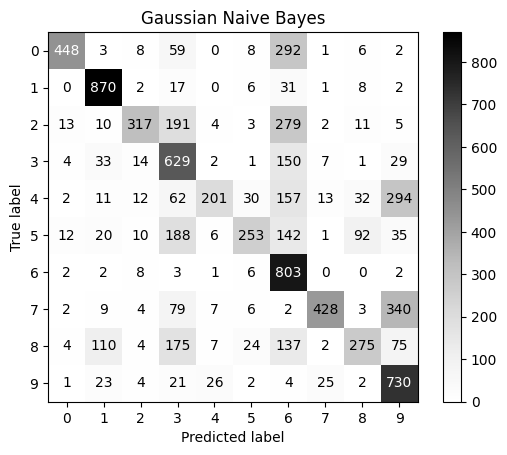

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred,
    cmap="Greys"
)

plt.title("Gaussian Naive Bayes")

plt.show()

# Compare Model Performance

The accuracies of all trained models are compared to identify the best-performing classifier.

In [57]:
accuracy_df = pd.DataFrame(
    model_accuracy.items(),
    columns=["Model", "Accuracy"]
)

accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_df

,Model,Accuracy
3,Random Forest,0.959881
1,KNN,0.924286
0,Logistic Regression,0.896786
2,Decision Tree,0.840000
4,Gaussian Naive Bayes,0.589762


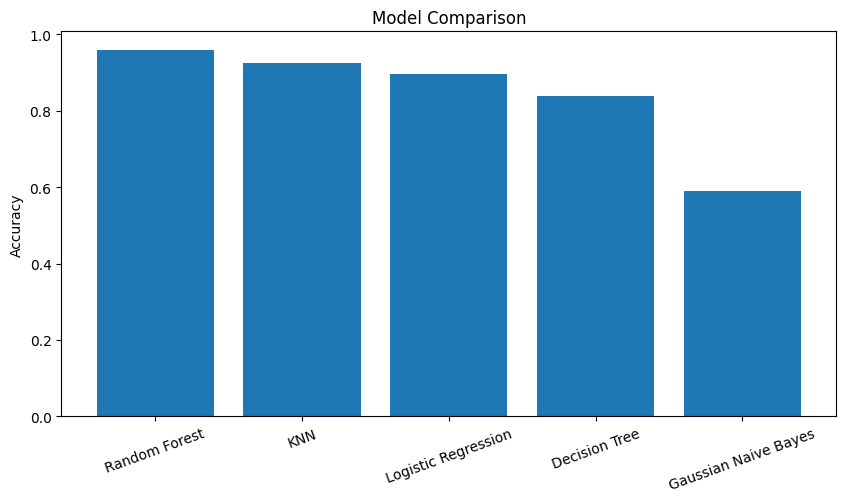

In [58]:
plt.figure(figsize=(10,5))

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

# Select the Best Model

Based on the accuracy scores, the best-performing model is selected for hyperparameter tuning.

In [59]:
best_model_name = accuracy_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Random Forest


# Hyperparameter Tuning using RandomizedSearchCV

After comparing all machine learning models, Random Forest achieved the highest accuracy.

To further improve the model's performance and identify the optimal hyperparameter combination, RandomizedSearchCV is applied.

Unlike GridSearchCV, RandomizedSearchCV randomly samples combinations from the parameter space, making it computationally efficient for large datasets.

In [62]:
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(100, 600),
    "max_depth": [10, 20, 30, 40, 50, None],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

In [67]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_random = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_dist,
    n_iter=1,          # Increase to 50 if you have more time
    scoring="accuracy",
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [68]:
random_search.fit(X_train, y_train)

Fitting 2 folds for each of 1 candidates, totalling 2 fits


RandomizedSearchCV(cv=2,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=1, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7bb39d61a840>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7bb39d61b290>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7bb39d618b00>},
                   random_state=42, scoring='accuracy', verbose=2)

In [69]:
print("Best Parameters:\n")

print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")

print(random_search.best_score_)

Best Parameters:

{'bootstrap': True, 'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 171}

Best Cross Validation Accuracy:
0.9494642857142856


In [70]:
best_rf = random_search.best_estimator_

best_rf

RandomForestClassifier(max_depth=40, min_samples_leaf=3, min_samples_split=4,
                       n_estimators=171, n_jobs=-1, random_state=42)

In [71]:
rf_tuned_pred = best_rf.predict(X_test)

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)

print("Random Forest Accuracy After Tuning :")

print(rf_tuned_accuracy)

Random Forest Accuracy After Tuning :
0.9554761904761905


In [72]:
print(classification_report(y_test, rf_tuned_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       827
           1       0.98      0.98      0.98       937
           2       0.95      0.95      0.95       835
           3       0.95      0.92      0.94       870
           4       0.97      0.95      0.96       814
           5       0.96      0.95      0.95       759
           6       0.96      0.98      0.97       827
           7       0.96      0.95      0.96       880
           8       0.95      0.93      0.94       813
           9       0.92      0.94      0.93       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400



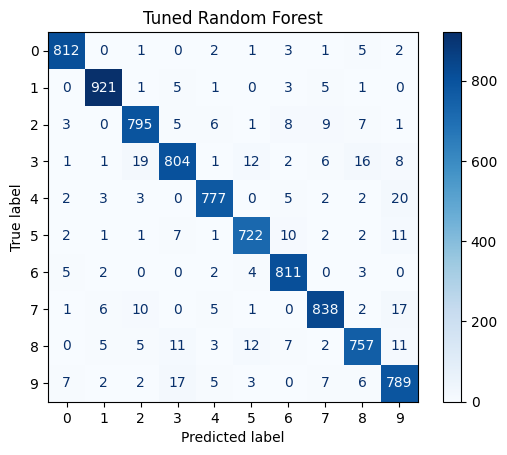

In [73]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_tuned_pred,
    cmap="Blues"
)

plt.title("Tuned Random Forest")

plt.show()

# Performance Comparison

The tuned Random Forest model is compared with the original Random Forest model to observe the improvement obtained after hyperparameter optimization.

In [74]:
comparison = pd.DataFrame({
    "Model": ["Random Forest (Before Tuning)", "Random Forest (After Tuning)"],
    "Accuracy": [rf_acc, rf_tuned_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest (Before Tuning),0.959881
1,Random Forest (After Tuning),0.955476


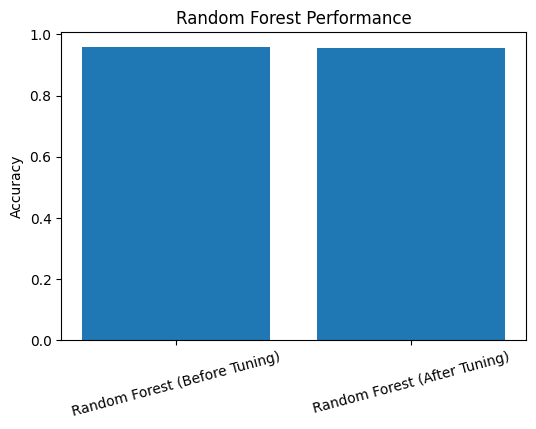

In [75]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.ylabel("Accuracy")

plt.title("Random Forest Performance")

plt.xticks(rotation=15)

plt.show()

# Save the Best Model

The tuned Random Forest model is saved using Joblib for future predictions without retraining.

In [76]:
import joblib

joblib.dump(best_rf, "random_forest_number_recognition.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully.")

Model Saved Successfully.


In [77]:
from google.colab import files

files.download("random_forest_number_recognition.pkl")

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>